In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.linear_model as sklin
import sklearn.model_selection as skms
import sklearn.preprocessing as skpre
import sklearn.impute as ski
import sklearn.metrics as skmet

In [2]:
# Set variables
missing_data_strat = 'drop'     # drop | impute

In [3]:
dataset_raw = pd.read_csv('../data/breast-cancer-wisconsin.data', header=None, delimiter=",")

# Replace missing values (denoted with ?) with nulls
dataset_raw = dataset_raw.replace('?', np.NaN)

# Convert columns to numeric where applicable
for col in dataset_raw.columns:
    dataset_raw[col] = pd.to_numeric(dataset_raw[col], errors='ignore')

# Alt 1 - Impute missing values using mean value of column
imputer = ski.SimpleImputer(missing_values = np.nan, strategy='mean')
dataset_imputed = pd.DataFrame(imputer.fit_transform(dataset_raw))

# Alt 2 - Drop columns with missing data
dataset_dropped = dataset_raw.dropna()

C:\Users\madam\AppData\Local\Temp\ipykernel_15472\1475440911.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dataset_raw[col] = pd.to_numeric(dataset_raw[col], errors='ignore')


In [4]:
if missing_data_strat == 'drop':
    dataset = dataset_dropped
elif missing_data_strat == 'impute':
    dataset = dataset_imputed
else:
    raise ValueError('missing_data_strat variable should be either "drop" or "impute"')

x = dataset.iloc[:, 1:-1].values   # drop first column containing unique identifier
y = dataset.iloc[:, -1].map({2: 0, 4: 1}).values    # raw data uses 2 / 4 for benign / malignant; map these to 0 / 1

In [5]:
x_train, x_test, y_train, y_test = skms.train_test_split(x, y, test_size=0.2)

# scalar = skpre.MinMaxScaler(feature_range=(0,1))
# x_train_norm = scalar.fit_transform(x_train)
# x_test_norm = scalar.fit_transform(x_test)

In [6]:
classifier = sklin.LogisticRegression()
classifier.fit(x_train, y_train)

y_pred = classifier.predict(x_test)
y_prob = classifier.predict_proba(x_test)

In [7]:
confusion_matrix = skmet.confusion_matrix(y_pred=y_pred, y_true=y_test)
accuracy_score = skmet.accuracy_score(y_pred=y_pred, y_true=y_test)

log_loss = skmet.log_loss(y_pred=y_prob, y_true=y_test)

print(confusion_matrix)
print(accuracy_score)
print(log_loss)

[[88  3]
 [ 3 43]]
0.9562043795620438
0.10304033536684376


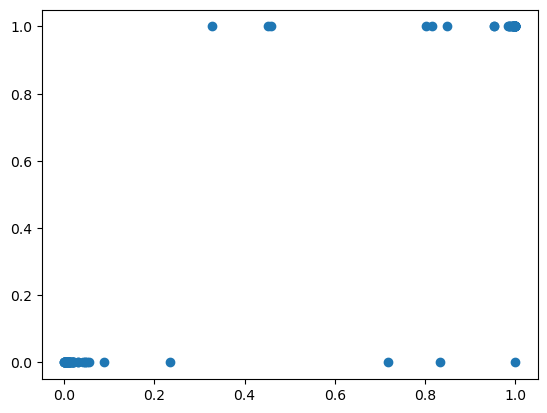

In [8]:
plt.scatter(y_prob[:,1], y_test)

In [9]:
accuracies = skms.cross_val_score(estimator=classifier, X=x_train, y=y_train, cv=10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 96.71 %
Standard Deviation: 2.93 %
